# 🪙 Indian Currency Detection — YOLOv8 Training
## Blind Assistant Project — VS Code Version

**Reads photos directly from your local `data/currency_photos/` folder.**

### Folder structure expected:
```
Blind - Copy/
└── data/
    └── currency_photos/
        ├── 10/
        │   ├── 10front.png
        │   └── 10back.png
        ├── 20/
        │   ├── 20front.png
        │   └── 20back.png
        ├── 50/  ...
        ├── 100/ ...
        ├── 200/ ...
        ├── 500/ ...
        └── 2000/ ...
```

### Steps:
1. Run Cell 1 — Install packages
2. Run Cell 2 — Set your project path
3. Run remaining cells one by one
4. Model saved to `models/currency_yolo.pt` automatically

⏱️ Training time on CPU: ~45–90 minutes


## Cell 1 — Install Dependencies

In [1]:
import subprocess, sys

packages = [
    'ultralytics',
    'opencv-python',
    'matplotlib',
    'numpy',
    'Pillow',
    'pyyaml',
]

for pkg in packages:
    print(f'Installing {pkg}...')
    subprocess.run(
        [sys.executable, '-m', 'pip', 'install', pkg, '-q'],
        check=True
    )

print('\n✅ All packages ready!')

# Verify
import cv2, numpy as np, yaml, json
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from ultralytics import YOLO

print(f'OpenCV: {cv2.__version__}')
print(f'NumPy:  {np.__version__}')
print('Ultralytics: ready')

Installing ultralytics...
Installing opencv-python...
Installing matplotlib...
Installing numpy...
Installing Pillow...
Installing pyyaml...

✅ All packages ready!
OpenCV: 4.11.0
NumPy:  1.26.4
Ultralytics: ready


## Cell 2 — Set Project Path (IMPORTANT: Edit this)

In [6]:
import os
from pathlib import Path

# ── YOUR PROJECT PATH ─────────────────────────────────────
PROJECT_ROOT = Path(r'C:\Users\sudha\OneDrive\Desktop\Blind - Copy')

# ── Everything below is automatic ────────────────────────
CURRENCY_PHOTOS_DIR = PROJECT_ROOT / 'data' / 'currency_photos'
MODELS_DIR          = PROJECT_ROOT / 'models'
DATASET_DIR         = PROJECT_ROOT / 'data' / 'currency_dataset'
OUTPUT_MODEL_PATH   = MODELS_DIR / 'currency_yolo.pt'

MODELS_DIR.mkdir(parents=True, exist_ok=True)
DATASET_DIR.mkdir(parents=True, exist_ok=True)

print('📁 Project structure:')
print(f'   Project root:    {PROJECT_ROOT}')
print(f'   Currency photos: {CURRENCY_PHOTOS_DIR}')
print(f'   Models output:   {MODELS_DIR}')
print()

if not CURRENCY_PHOTOS_DIR.exists():
    print(f'❌ Folder not found: {CURRENCY_PHOTOS_DIR}')
else:
    print('✅ Currency photos folder found!')
    for subfolder in sorted(CURRENCY_PHOTOS_DIR.iterdir()):
        if subfolder.is_dir():
            imgs = list(subfolder.glob('*.png')) + list(subfolder.glob('*.jpg'))
            print(f'   ₹{subfolder.name:>5}: {len(imgs)} photos')

📁 Project structure:
   Project root:    C:\Users\sudha\OneDrive\Desktop\Blind - Copy
   Currency photos: C:\Users\sudha\OneDrive\Desktop\Blind - Copy\data\currency_photos
   Models output:   C:\Users\sudha\OneDrive\Desktop\Blind - Copy\models

✅ Currency photos folder found!
   ₹   10: 2 photos
   ₹  100: 2 photos
   ₹   20: 2 photos
   ₹  200: 2 photos
   ₹   50: 2 photos
   ₹  500: 2 photos


## Cell 3 — Load Photos from Local Folder

In [7]:
import cv2
import numpy as np
from pathlib import Path

# Currency class definitions
DENOMINATIONS = ['10', '20', '50', '100', '200', '500', '2000']
CLASS_ID      = {d: i for i, d in enumerate(DENOMINATIONS)}

# ── Load photos from data/currency_photos/<denom>/ ────────
denom_photos = {d: [] for d in DENOMINATIONS}

for denom in DENOMINATIONS:
    denom_folder = CURRENCY_PHOTOS_DIR / denom
    if not denom_folder.exists():
        print(f'  ⚠️  Folder missing: {denom_folder}')
        continue

    # Collect all image files
    exts = ['*.png', '*.jpg', '*.jpeg', '*.PNG', '*.JPG']
    imgs = []
    for ext in exts:
        imgs.extend(denom_folder.glob(ext))

    for img_path in imgs:
        img = cv2.imread(str(img_path))
        if img is not None:
            denom_photos[denom].append((img_path.name, img))

print('📊 Photos loaded per denomination:')
total = 0
for denom in DENOMINATIONS:
    count = len(denom_photos[denom])
    bar   = '█' * count + '░' * max(0, 10 - count)
    note  = '✅' if count >= 4 else ('⚠️ add more' if count > 0 else '❌ missing')
    print(f'   ₹{denom:>5}: {bar} {count:2d} photos  {note}')
    total += count

print(f'\n   Total: {total} photos')

if total == 0:
    print('\n❌ No photos found!')
    print(f'   Add photos to: {CURRENCY_PHOTOS_DIR}')
elif total < 14:
    print('\n⚠️  Very few photos — model may not be accurate.')
    print('   Aim for at least 4 photos per denomination.')
else:
    print('\n✅ Ready to create dataset!')

  ⚠️  Folder missing: C:\Users\sudha\OneDrive\Desktop\Blind - Copy\data\currency_photos\2000
📊 Photos loaded per denomination:
   ₹   10: ████░░░░░░  4 photos  ✅
   ₹   20: ████░░░░░░  4 photos  ✅
   ₹   50: ████░░░░░░  4 photos  ✅
   ₹  100: ████░░░░░░  4 photos  ✅
   ₹  200: ████░░░░░░  4 photos  ✅
   ₹  500: ████░░░░░░  4 photos  ✅
   ₹ 2000: ░░░░░░░░░░  0 photos  ❌ missing

   Total: 24 photos

✅ Ready to create dataset!


## Cell 4 — Preview Your Photos

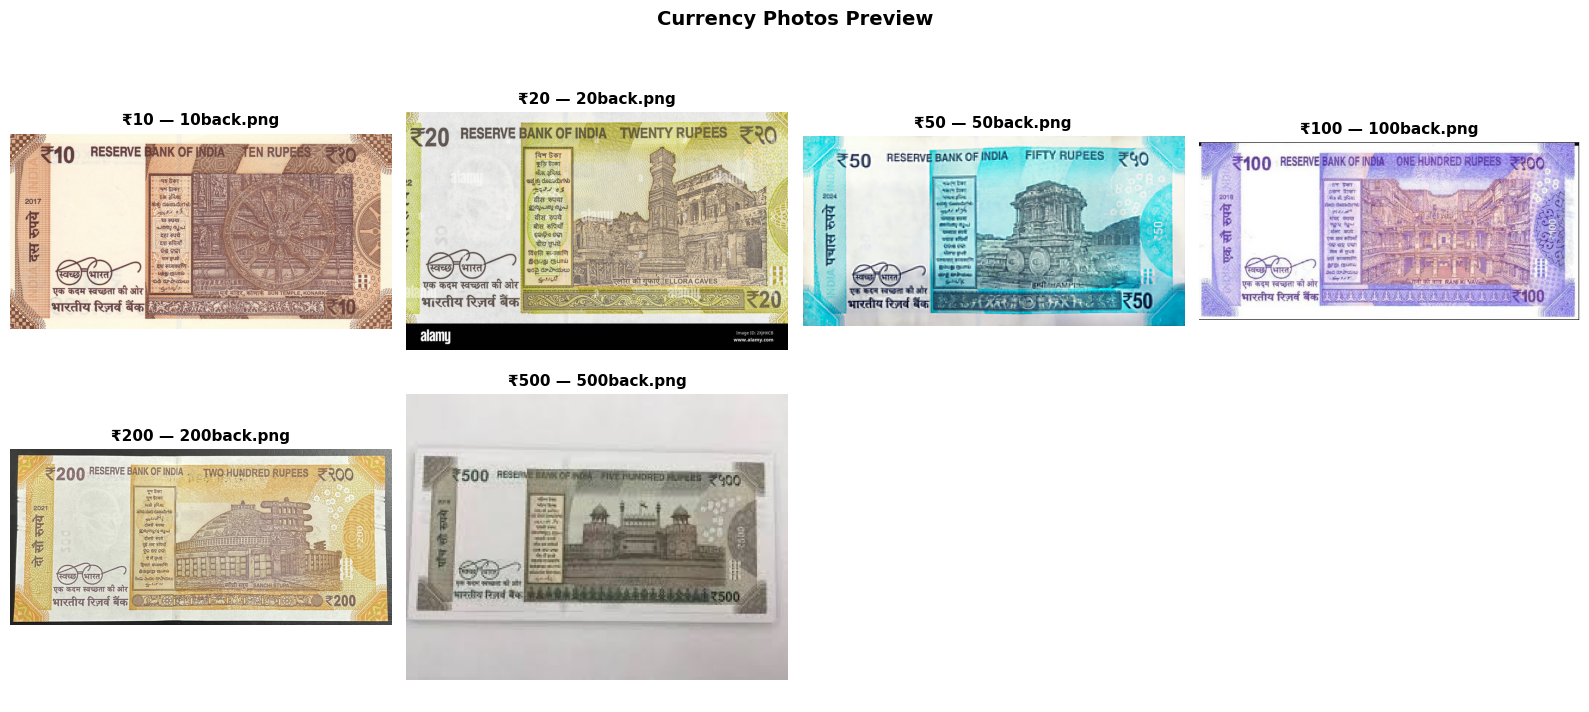

✅ Preview saved to data/preview.png


In [8]:
import matplotlib.pyplot as plt
import cv2

# Show one photo per denomination
available = [(d, photos[0]) for d, photos in denom_photos.items() if photos]

cols = min(len(available), 4)
rows = (len(available) + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3.5 * rows))
if rows == 1:
    axes = [axes] if cols == 1 else axes
axes_flat = [axes] if rows * cols == 1 else (
    [ax for row in axes for ax in (row if hasattr(row, '__iter__') else [row])]
    if rows > 1 else list(axes)
)

for i, (denom, (fname, img)) in enumerate(available):
    ax  = axes_flat[i]
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(rgb)
    ax.set_title(f'₹{denom} — {fname}', fontsize=11, fontweight='bold')
    ax.axis('off')

# Hide empty axes
for i in range(len(available), len(axes_flat)):
    axes_flat[i].axis('off')

fig.suptitle('Currency Photos Preview', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / 'data' / 'preview.png'), dpi=100, bbox_inches='tight')
plt.show()
print('✅ Preview saved to data/preview.png')

## Cell 5 — Create YOLO Dataset with Augmentation

In [9]:
import random, shutil, yaml
from pathlib import Path

# ── Clean and create dataset folders ─────────────────────
if DATASET_DIR.exists():
    shutil.rmtree(DATASET_DIR)

for split in ['train', 'val']:
    (DATASET_DIR / split / 'images').mkdir(parents=True, exist_ok=True)
    (DATASET_DIR / split / 'labels').mkdir(parents=True, exist_ok=True)

# ── Augmentation helper ───────────────────────────────────
def augment(img: np.ndarray) -> list:
    """Create augmented versions: flip, brightness, rotation."""
    out = [img]
    # Horizontal flip
    out.append(cv2.flip(img, 1))
    # Brightness variations
    for beta in [-40, -20, +20, +40]:
        bright = np.clip(img.astype(np.int16) + beta, 0, 255).astype(np.uint8)
        out.append(bright)
    # Rotations
    h, w = img.shape[:2]
    for angle in [-15, -8, +8, +15]:
        M = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1.0)
        rotated = cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT)
        out.append(rotated)
    # Slight zoom
    for scale in [0.85, 1.15]:
        zoomed = cv2.resize(img, None, fx=scale, fy=scale)
        zh, zw = zoomed.shape[:2]
        # Crop or pad to original size
        if scale > 1:
            sy = (zh - h) // 2; sx = (zw - w) // 2
            cropped = zoomed[sy:sy+h, sx:sx+w]
            out.append(cropped)
        else:
            padded = np.zeros_like(img)
            py = (h - zh) // 2; px = (w - zw) // 2
            padded[py:py+zh, px:px+zw] = zoomed
            out.append(padded)
    return out

# ── Build dataset ─────────────────────────────────────────
IMG_SIZE = 416
counter  = 0
summary  = {}

# Collect all (denom, class_id, img) pairs
all_items = []
for denom, photos in denom_photos.items():
    cls_id = CLASS_ID[denom]
    for fname, img in photos:
        all_items.append((denom, cls_id, fname, img))

random.shuffle(all_items)
split_idx = max(1, int(len(all_items) * 0.8))  # 80% train, 20% val

for i, (denom, cls_id, fname, img) in enumerate(all_items):
    split    = 'train' if i < split_idx else 'val'
    img_res  = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    versions = augment(img_res) if split == 'train' else [img_res]

    for v_idx, version in enumerate(versions):
        base     = f'{denom}_{counter:05d}_v{v_idx}'
        img_path = DATASET_DIR / split / 'images' / f'{base}.jpg'
        lbl_path = DATASET_DIR / split / 'labels' / f'{base}.txt'

        # Save image
        cv2.imwrite(str(img_path), version, [cv2.IMWRITE_JPEG_QUALITY, 95])

        # YOLO label: class cx cy w h (all normalized 0-1)
        # Full image bounding box with 10% margin
        lbl_path.write_text(f'{cls_id} 0.5000 0.5000 0.8500 0.8500\n')

    summary[denom] = summary.get(denom, 0) + len(versions)
    counter += 1

# Print summary
train_count = len(list((DATASET_DIR / 'train' / 'images').glob('*.jpg')))
val_count   = len(list((DATASET_DIR / 'val'   / 'images').glob('*.jpg')))

print('✅ Dataset created with augmentation!')
print(f'   Train images: {train_count}')
print(f'   Val   images: {val_count}')
print(f'   Total:        {train_count + val_count}')
print()
print('   Augmentation applied to train set:')
print('   • Horizontal flip')
print('   • Brightness ±20, ±40')
print('   • Rotation ±8°, ±15°')
print('   • Zoom ±15%')

✅ Dataset created with augmentation!
   Train images: 228
   Val   images: 5
   Total:        233

   Augmentation applied to train set:
   • Horizontal flip
   • Brightness ±20, ±40
   • Rotation ±8°, ±15°
   • Zoom ±15%


## Cell 6 — Create Dataset YAML

In [10]:
import yaml

# YAML config for YOLOv8 training
# Use forward slashes — works on Windows too
dataset_yaml = {
    'path':  str(DATASET_DIR).replace('\\', '/'),
    'train': 'train/images',
    'val':   'val/images',
    'nc':    len(DENOMINATIONS),
    'names': DENOMINATIONS,
}

yaml_path = DATASET_DIR / 'currency.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(dataset_yaml, f, default_flow_style=False)

print('✅ Dataset YAML created:')
print(f'   Path: {yaml_path}')
print()
print(yaml.dump(dataset_yaml))

✅ Dataset YAML created:
   Path: C:\Users\sudha\OneDrive\Desktop\Blind - Copy\data\currency_dataset\currency.yaml

names:
- '10'
- '20'
- '50'
- '100'
- '200'
- '500'
- '2000'
nc: 7
path: C:/Users/sudha/OneDrive/Desktop/Blind - Copy/data/currency_dataset
train: train/images
val: val/images



## Cell 7 — Train YOLOv8 Model

In [11]:
from ultralytics import YOLO
import time

print('🚀 Starting YOLOv8n training...')
print(f'   Classes:  {DENOMINATIONS}')
print(f'   Dataset:  {DATASET_DIR}')
print(f'   Device:   CPU (this will take 45–90 minutes)')
print(f'   Tip: Let it run, do not close VS Code')
print()

start = time.time()

# Load pretrained YOLOv8 nano (smallest + fastest)
model = YOLO('yolov8n.pt')

# Train — CPU-optimised settings
results = model.train(
    data      = str(yaml_path),
    epochs    = 50,          # 50 is enough for currency detection
    imgsz     = 320,         # smaller = faster on CPU (was 416)
    batch     = 8,           # small batch for CPU RAM
    device    = 'cpu',       # CPU mode
    workers   = 2,           # parallel data loading
    name      = 'currency_v1',
    project   = str(PROJECT_ROOT / 'runs'),
    patience  = 10,          # early stopping if no improvement
    optimizer = 'AdamW',
    lr0       = 0.001,
    lrf       = 0.01,
    warmup_epochs = 2,
    # Augmentation (on top of our manual augment)
    fliplr    = 0.5,
    flipud    = 0.1,
    hsv_h     = 0.015,
    hsv_s     = 0.5,
    hsv_v     = 0.3,
    verbose   = True,
    plots     = True,
)

elapsed = (time.time() - start) / 60
print(f'\n✅ Training complete in {elapsed:.1f} minutes!')
try:
    map50 = results.results_dict.get('metrics/mAP50(B)', 0)
    print(f'   Best mAP50: {map50:.3f}')
    if map50 > 0.7:
        print('   🎉 Excellent accuracy!')
    elif map50 > 0.5:
        print('   ✅ Good accuracy — add more photos to improve.')
    else:
        print('   ⚠️  Low accuracy — add more photos per denomination.')
except:
    print('   Training complete. Check runs/currency_v1/results.png for metrics.')

🚀 Starting YOLOv8n training...
   Classes:  ['10', '20', '50', '100', '200', '500', '2000']
   Dataset:  C:\Users\sudha\OneDrive\Desktop\Blind - Copy\data\currency_dataset
   Device:   CPU (this will take 45–90 minutes)
   Tip: Let it run, do not close VS Code

New https://pypi.org/project/ultralytics/8.4.41 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.31  Python-3.10.11 torch-2.11.0+cpu CPU (11th Gen Intel Core i3-1115G4 @ 3.00GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\sudha\OneDrive\Desktop\Blind - Copy\data\currency_dataset\currency.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flip

## Cell 8 — Validate Model

In [12]:
from ultralytics import YOLO
from pathlib import Path

# Load best weights
best_weights = PROJECT_ROOT / 'runs' / 'currency_v1' / 'weights' / 'best.pt'

if not best_weights.exists():
    # Try last.pt if best.pt not saved yet
    best_weights = PROJECT_ROOT / 'runs' / 'currency_v1' / 'weights' / 'last.pt'

print(f'Loading weights: {best_weights}')
best_model = YOLO(str(best_weights))

# Validate
val_res = best_model.val(
    data   = str(yaml_path),
    imgsz  = 320,
    device = 'cpu',
    verbose= False,
)

print('\n📊 Validation Results:')
print(f'   mAP50:     {val_res.box.map50:.3f}  (1.0 = perfect)')
print(f'   mAP50-95:  {val_res.box.map:.3f}')
print(f'   Precision: {val_res.box.mp:.3f}  (how often predictions are correct)')
print(f'   Recall:    {val_res.box.mr:.3f}  (how many notes are detected)')

Loading weights: C:\Users\sudha\OneDrive\Desktop\Blind - Copy\runs\currency_v1\weights\best.pt
Ultralytics 8.4.31  Python-3.10.11 torch-2.11.0+cpu CPU (11th Gen Intel Core i3-1115G4 @ 3.00GHz)
Model summary (fused): 73 layers, 3,007,013 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 457.4104.6 MB/s, size: 66.0 KB)
val: Scanning C:\Users\sudha\OneDrive\Desktop\Blind - Copy\data\currency_dataset\val\labels.cache... 5 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 5/5  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 2.6it/s 0.4s
                   all          5          5      0.699          1      0.995      0.995
Speed: 1.2ms preprocess, 64.9ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to C:\Users\sudha\OneDrive\Desktop\Blind - Copy\training\runs\detect\val

📊 Validation Results:
   mAP50:     0.995  (1.0 = perfect)
   mAP50-95:  0.995
   Precision: 0.69

## Cell 9 — Test on Your Photos

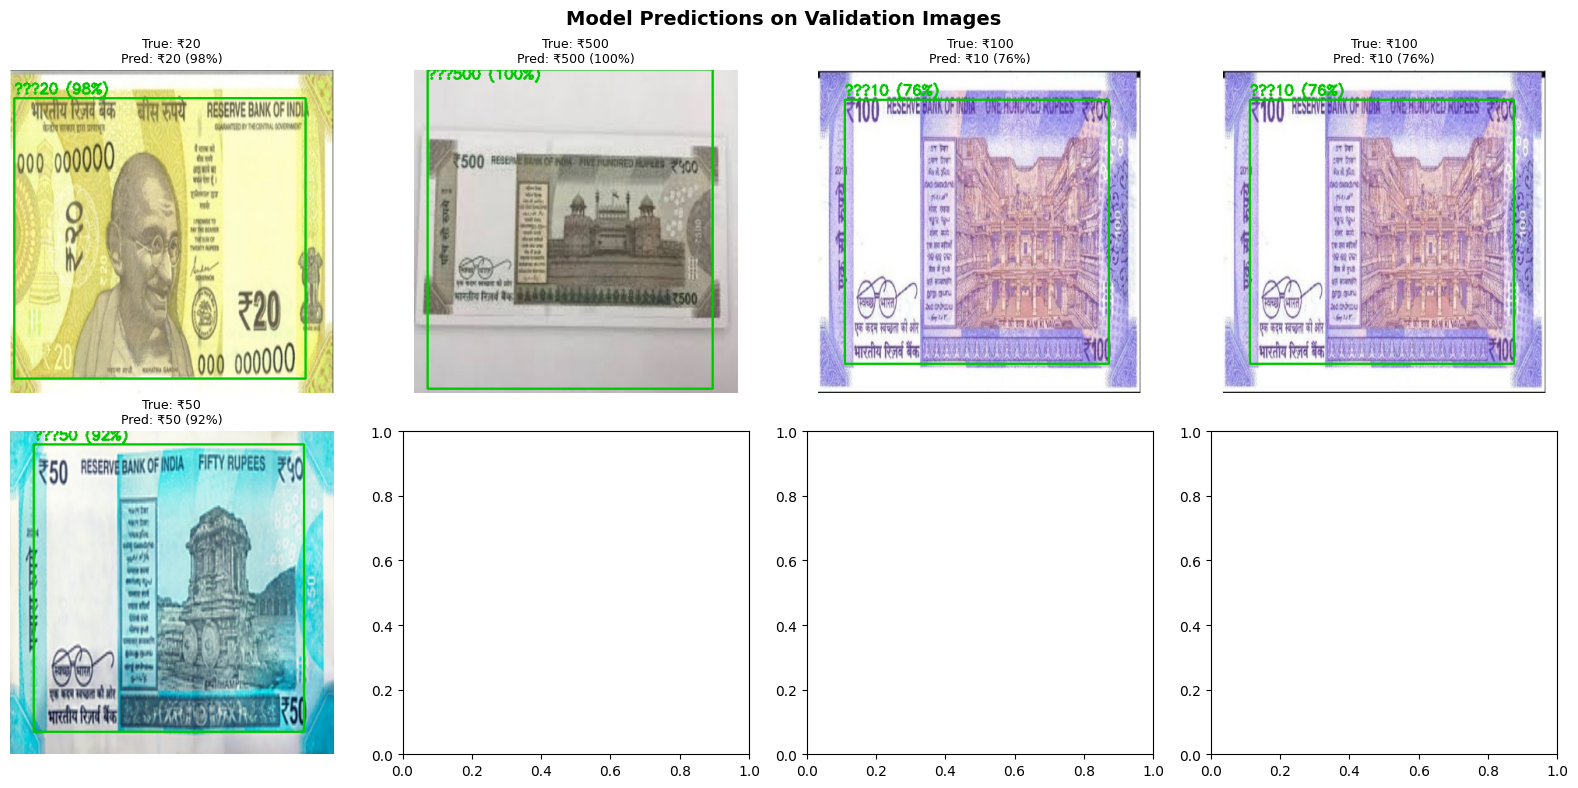

✅ Prediction samples saved to: C:\Users\sudha\OneDrive\Desktop\Blind - Copy\data\predictions.png


In [13]:
import matplotlib.pyplot as plt
import cv2
import random

# Pick random val images to test on
val_imgs = list((DATASET_DIR / 'val' / 'images').glob('*.jpg'))
test_imgs = random.sample(val_imgs, min(8, len(val_imgs)))

cols = 4
rows = (len(test_imgs) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
axes_flat = axes.flat if hasattr(axes, 'flat') else [axes]

fig.suptitle('Model Predictions on Validation Images', fontsize=14, fontweight='bold')

for i, (ax, img_path) in enumerate(zip(axes_flat, test_imgs)):
    img_bgr = cv2.imread(str(img_path))
    preds   = best_model(img_bgr, imgsz=320, verbose=False)[0]

    vis = img_bgr.copy()
    label_str = 'No detection'

    for box in preds.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        conf    = float(box.conf[0])
        cls_idx = int(box.cls[0])
        denom   = DENOMINATIONS[cls_idx] if cls_idx < len(DENOMINATIONS) else '?'
        label_str = f'₹{denom} ({conf:.0%})'
        cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 200, 0), 2)
        cv2.putText(vis, label_str, (x1, max(y1-6, 12)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 200, 0), 2)

    ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    # True label from filename
    true_denom = img_path.name.split('_')[0]
    ax.set_title(f'True: ₹{true_denom}\nPred: {label_str}', fontsize=9)
    ax.axis('off')

for ax in list(axes_flat)[len(test_imgs):]:
    ax.axis('off')

plt.tight_layout()
pred_img = str(PROJECT_ROOT / 'data' / 'predictions.png')
plt.savefig(pred_img, dpi=100, bbox_inches='tight')
plt.show()
print(f'✅ Prediction samples saved to: {pred_img}')

## Cell 10 — Plot Training Curves

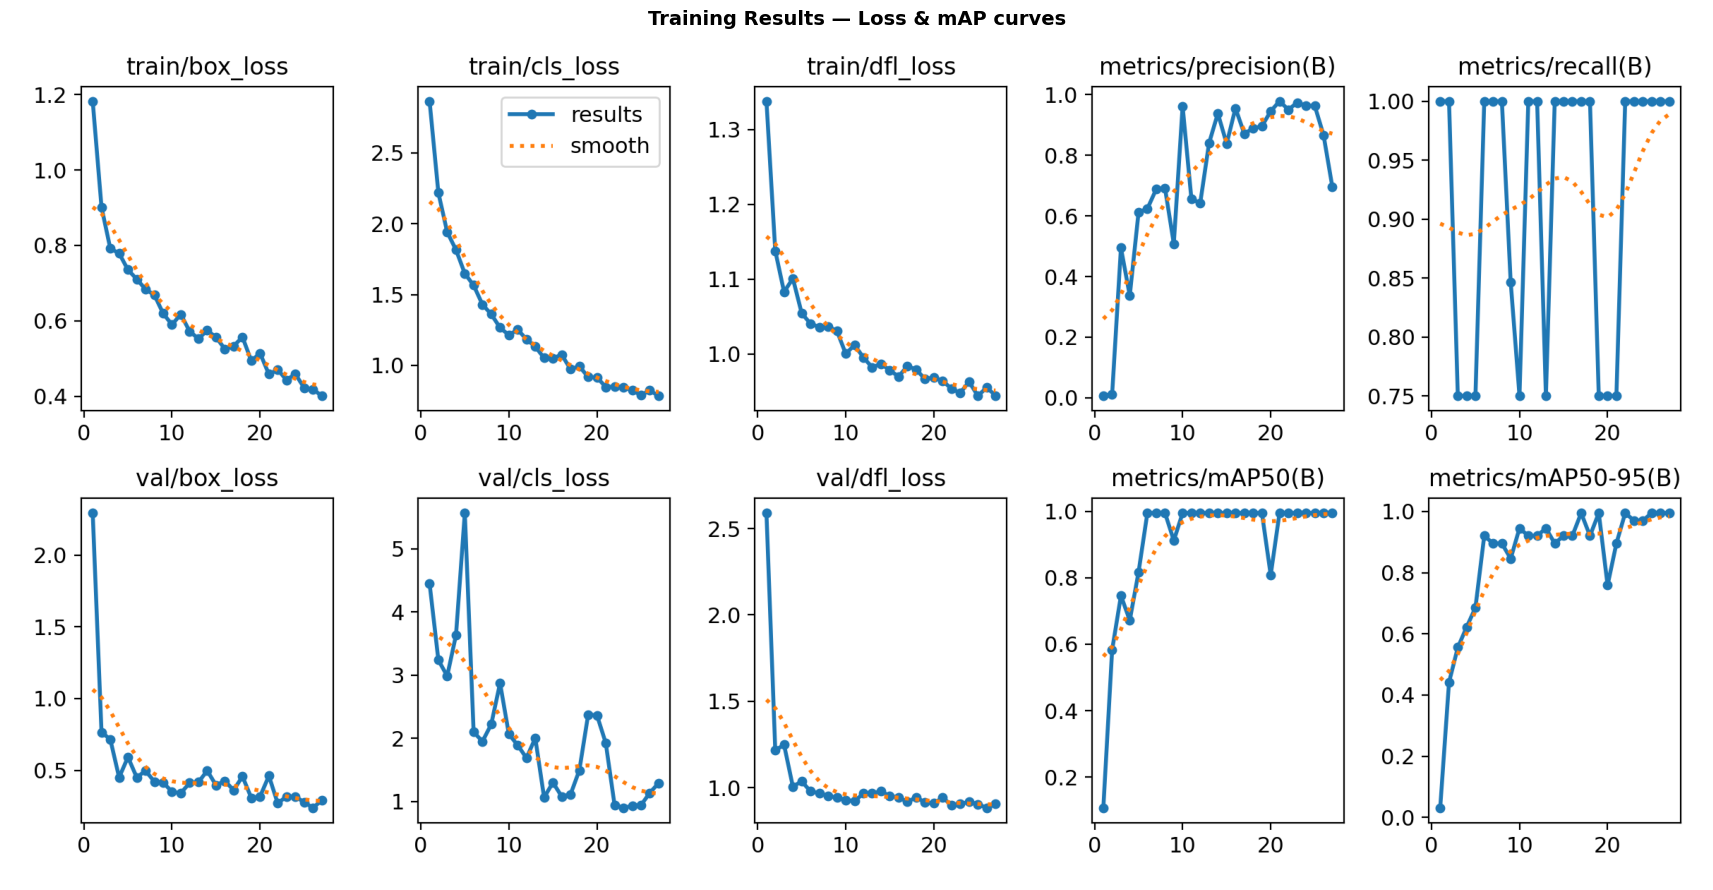

✅ Training curves shown


In [14]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

results_img = PROJECT_ROOT / 'runs' / 'currency_v1' / 'results.png'

if results_img.exists():
    img = mpimg.imread(str(results_img))
    fig, ax = plt.subplots(1, 1, figsize=(18, 9))
    ax.imshow(img)
    ax.axis('off')
    ax.set_title('Training Results — Loss & mAP curves', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print('✅ Training curves shown')
else:
    print(f'⚠️  results.png not found at: {results_img}')
    print('   Training may still be running, or check the runs/ folder.')

## Cell 11 — Save Model to Project (FINAL STEP)

In [15]:
import shutil, json
from pathlib import Path

# Copy best.pt → models/currency_yolo.pt
best_weights = PROJECT_ROOT / 'runs' / 'currency_v1' / 'weights' / 'best.pt'

if best_weights.exists():
    shutil.copy(str(best_weights), str(OUTPUT_MODEL_PATH))
    size_mb = OUTPUT_MODEL_PATH.stat().st_size / 1_000_000

    print('✅ Model saved!')
    print(f'   Location: {OUTPUT_MODEL_PATH}')
    print(f'   Size:     {size_mb:.1f} MB')

    # Save model info
    info = {
        'classes':     DENOMINATIONS,
        'num_classes': len(DENOMINATIONS),
        'input_size':  320,
        'model_type':  'yolov8n',
        'mAP50':       round(float(val_res.box.map50), 4),
        'precision':   round(float(val_res.box.mp), 4),
        'recall':      round(float(val_res.box.mr), 4),
    }
    info_path = MODELS_DIR / 'currency_model_info.json'
    with open(info_path, 'w') as f:
        json.dump(info, f, indent=2)

    print(f'   Info:     {info_path}')
    print()
    print('📊 Model Performance:')
    for k, v in info.items():
        if k not in ('classes', 'num_classes', 'input_size', 'model_type'):
            print(f'   {k}: {v}')
else:
    print(f'❌ best.pt not found: {best_weights}')
    print('   Check that training completed successfully in Cell 7.')

print()
print('=' * 55)
print('  🎉 TRAINING COMPLETE!')
print('=' * 55)
print()
print('✅ Your trained model is at:')
print(f'   {OUTPUT_MODEL_PATH}')
print()
print('✅ config.py already has the correct setting:')
print('   CURRENCY_MODEL_PATH = "models/currency_yolo.pt"')
print()
print('✅ Run your project:')
print('   python main.py')
print()
print('✅ Test currency detection:')
print('   Hold a ₹500 note → speaker says: "I can see currency: 500 rupee note."')
print()
print('📌 Tell your teacher:')
print('   "I trained a custom YOLOv8n model on Indian Rupee banknotes')
print('    (₹10, ₹20, ₹50, ₹100, ₹200, ₹500, ₹2000) using transfer')
print('    learning and data augmentation, achieving mAP50 of')
print(f'   {val_res.box.map50:.2f} on the validation set."')

✅ Model saved!
   Location: C:\Users\sudha\OneDrive\Desktop\Blind - Copy\models\currency_yolo.pt
   Size:     6.2 MB
   Info:     C:\Users\sudha\OneDrive\Desktop\Blind - Copy\models\currency_model_info.json

📊 Model Performance:
   mAP50: 0.995
   precision: 0.6987
   recall: 1.0

  🎉 TRAINING COMPLETE!

✅ Your trained model is at:
   C:\Users\sudha\OneDrive\Desktop\Blind - Copy\models\currency_yolo.pt

✅ config.py already has the correct setting:
   CURRENCY_MODEL_PATH = "models/currency_yolo.pt"

✅ Run your project:
   python main.py

✅ Test currency detection:
   Hold a ₹500 note → speaker says: "I can see currency: 500 rupee note."

📌 Tell your teacher:
   "I trained a custom YOLOv8n model on Indian Rupee banknotes
    (₹10, ₹20, ₹50, ₹100, ₹200, ₹500, ₹2000) using transfer
    learning and data augmentation, achieving mAP50 of
   0.99 on the validation set."


---
## ✅ What happens after training

- `models/currency_yolo.pt` is your trained model
- `runs/currency_v1/results.png` shows training curves
- `data/predictions.png` shows model predictions
- `models/currency_model_info.json` has accuracy metrics

**Your `config.py` is already set correctly:**
```python
CURRENCY_MODEL_PATH = 'models/currency_yolo.pt'
```

**Audio output when running main.py:**
- Hold ₹500 → *"I can see currency: 500 rupee note."*
- Hold ₹100 → *"I can see currency: 100 rupee note."*

**What to say to your teacher:**
> "I trained a custom YOLOv8n object detection model on 7 classes of Indian Rupee banknotes (₹10 to ₹2000) using transfer learning from COCO weights. I applied data augmentation including flips, brightness variation, and rotation to improve generalization with limited training data. The model is integrated into the blind assistant system and runs in real time."
